In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/online_retail.csv', encoding='latin1')
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2022-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2022-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2022-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2022-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2022-12-01 08:26:00       3.39     17850.0  United Kingdom  
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country   

In [2]:
# ============================================
# BLOCK 2: DATA PREPROCESSING
# ============================================

# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled invoices (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative/zero quantity and price
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Convert types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print("✅ Clean data shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nFirst few rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

✅ Clean data shape: (397884, 9)

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int32
Country                object
TotalAmount           float64
dtype: object

First few rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalAmount  
0 2022-12-01 08:26:00       2.55       17850  United Kingdom        15.30  
1 2022-12-01 08:26:00       3.39       17850  United Kingdom        2

TOP 10 COUNTRIES BY TRANSACTIONS


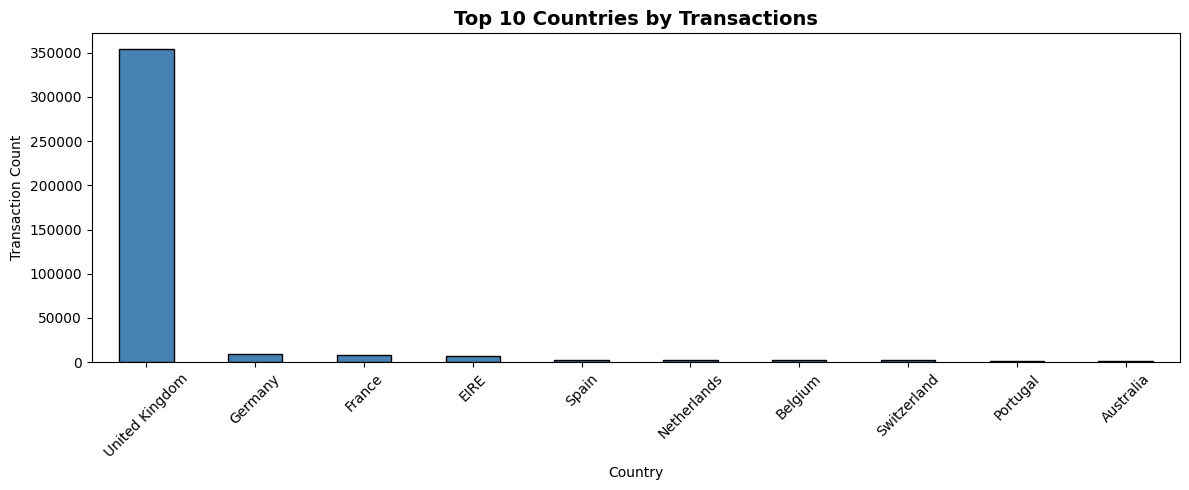

Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1462
Australia           1182
Name: count, dtype: int64

TOP 10 BEST SELLING PRODUCTS


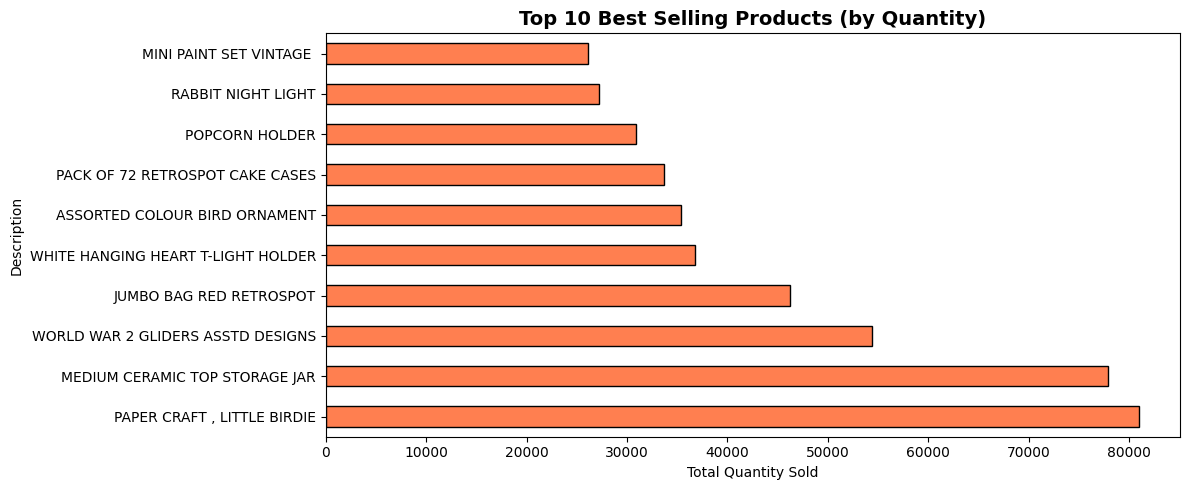


MONTHLY REVENUE TREND


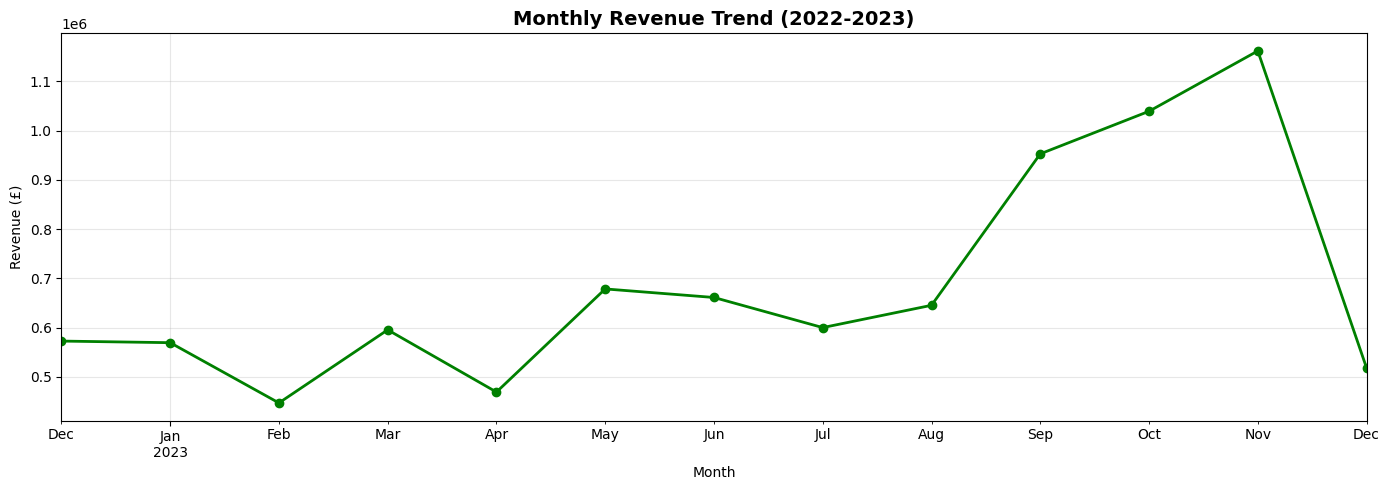


TRANSACTION AMOUNT DISTRIBUTION


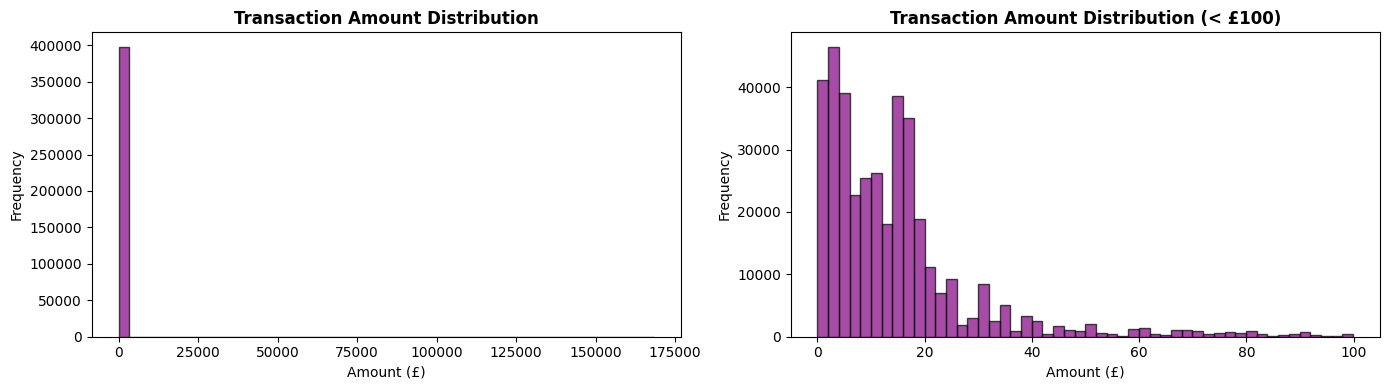


Transaction amount statistics:
count    397884.000000
mean         22.397000
std         309.071041
min           0.001000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: TotalAmount, dtype: float64

DATA OVERVIEW
Total Transactions: 397,884
Unique Customers: 4,338
Unique Products: 3,877
Countries: 37
Date Range: 2022-12-01 08:26:00 to 2023-12-09 12:50:00


In [3]:
# ============================================
# BLOCK 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

# 1. Top 10 countries by transaction volume
print("=" * 50)
print("TOP 10 COUNTRIES BY TRANSACTIONS")
print("=" * 50)
plt.figure(figsize=(12, 5))
df['Country'].value_counts().head(10).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 Countries by Transactions', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../assets/eda_countries.png', dpi=300, bbox_inches='tight')
plt.show()
print(df['Country'].value_counts().head(10))

# 2. Top 10 products by quantity sold
print("\n" + "=" * 50)
print("TOP 10 BEST SELLING PRODUCTS")
print("=" * 50)
plt.figure(figsize=(12, 5))
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10).plot(
    kind='barh', color='coral', edgecolor='black')
plt.title('Top 10 Best Selling Products (by Quantity)', fontsize=14, fontweight='bold')
plt.xlabel('Total Quantity Sold')
plt.tight_layout()
plt.savefig('../assets/eda_products.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Monthly revenue trend
print("\n" + "=" * 50)
print("MONTHLY REVENUE TREND")
print("=" * 50)
monthly_revenue = df.set_index('InvoiceDate')['TotalAmount'].resample('M').sum()
plt.figure(figsize=(14, 5))
monthly_revenue.plot(color='green', linewidth=2, marker='o')
plt.title('Monthly Revenue Trend (2022-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../assets/eda_trend.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Transaction amount distribution
print("\n" + "=" * 50)
print("TRANSACTION AMOUNT DISTRIBUTION")
print("=" * 50)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['TotalAmount'], bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[0].set_title('Transaction Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Amount (£)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df[df['TotalAmount'] < 100]['TotalAmount'], bins=50, color='purple', 
             edgecolor='black', alpha=0.7)
axes[1].set_title('Transaction Amount Distribution (< £100)', fontweight='bold')
axes[1].set_xlabel('Amount (£)')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('../assets/eda_amount_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTransaction amount statistics:")
print(df['TotalAmount'].describe())

# 5. Unique customers and products
print("\n" + "=" * 50)
print("DATA OVERVIEW")
print("=" * 50)
print(f"Total Transactions: {len(df):,}")
print(f"Unique Customers: {df['CustomerID'].nunique():,}")
print(f"Unique Products: {df['Description'].nunique():,}")
print(f"Countries: {df['Country'].nunique():,}")
print(f"Date Range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")